In [25]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm

In [78]:
prices = np.loadtxt('PRICES.txt')[:500]
prices = prices.T

In [80]:
prices

array([[13.46, 13.48, 13.47, ..., 13.69, 13.55, 13.4 ],
       [71.65, 72.1 , 72.35, ..., 67.83, 67.61, 67.33],
       [48.46, 48.52, 48.48, ..., 46.66, 46.73, 46.72],
       ...,
       [36.22, 36.27, 36.39, ..., 33.6 , 33.79, 33.82],
       [49.  , 48.84, 48.56, ..., 33.75, 33.53, 33.4 ],
       [56.09, 56.08, 55.9 , ..., 54.22, 54.5 , 55.01]])

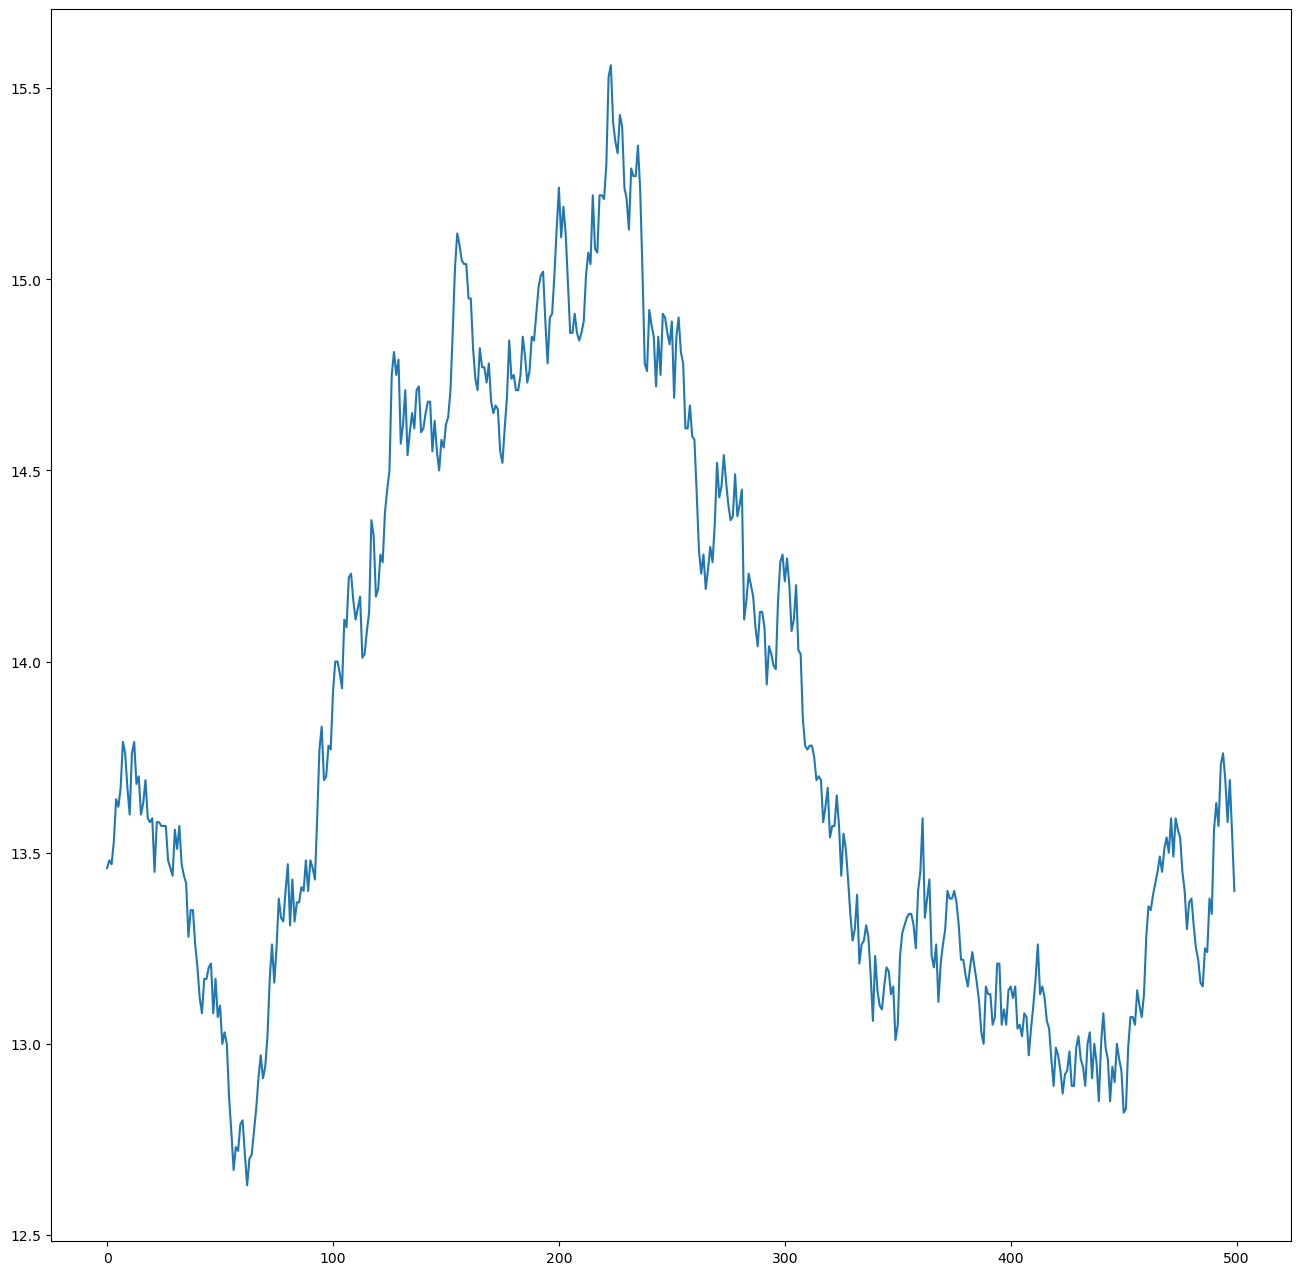

In [82]:
fig, ax = subplots(figsize = (16, 16))
ax.plot(prices[0])

In [84]:
def normalize(prices):
    p_max = np.max(prices)
    p_min = np.min(prices)
    normalized_p = []

    for price in prices:
        normalized_p.append((price - p_min) / (p_max - p_min))

    return normalized_p

def distance(p1, p2):
    p1 = normalize(p1)
    p2 = normalize(p2)
    
    sds = 0
    
    for i in range(len(p1)):
        sds += (p1[i] - p2[i]) ** 2

    return sds  

In [86]:
distances = []
for i, price1 in enumerate(prices):
    for j, price2 in enumerate(prices):
        if i != j:
            distances.append([distance(prices[i], prices[j]), i, j])
min_d = min(distances, key=lambda x: x[0])
min_d

[3.133142189080245, 27, 42]

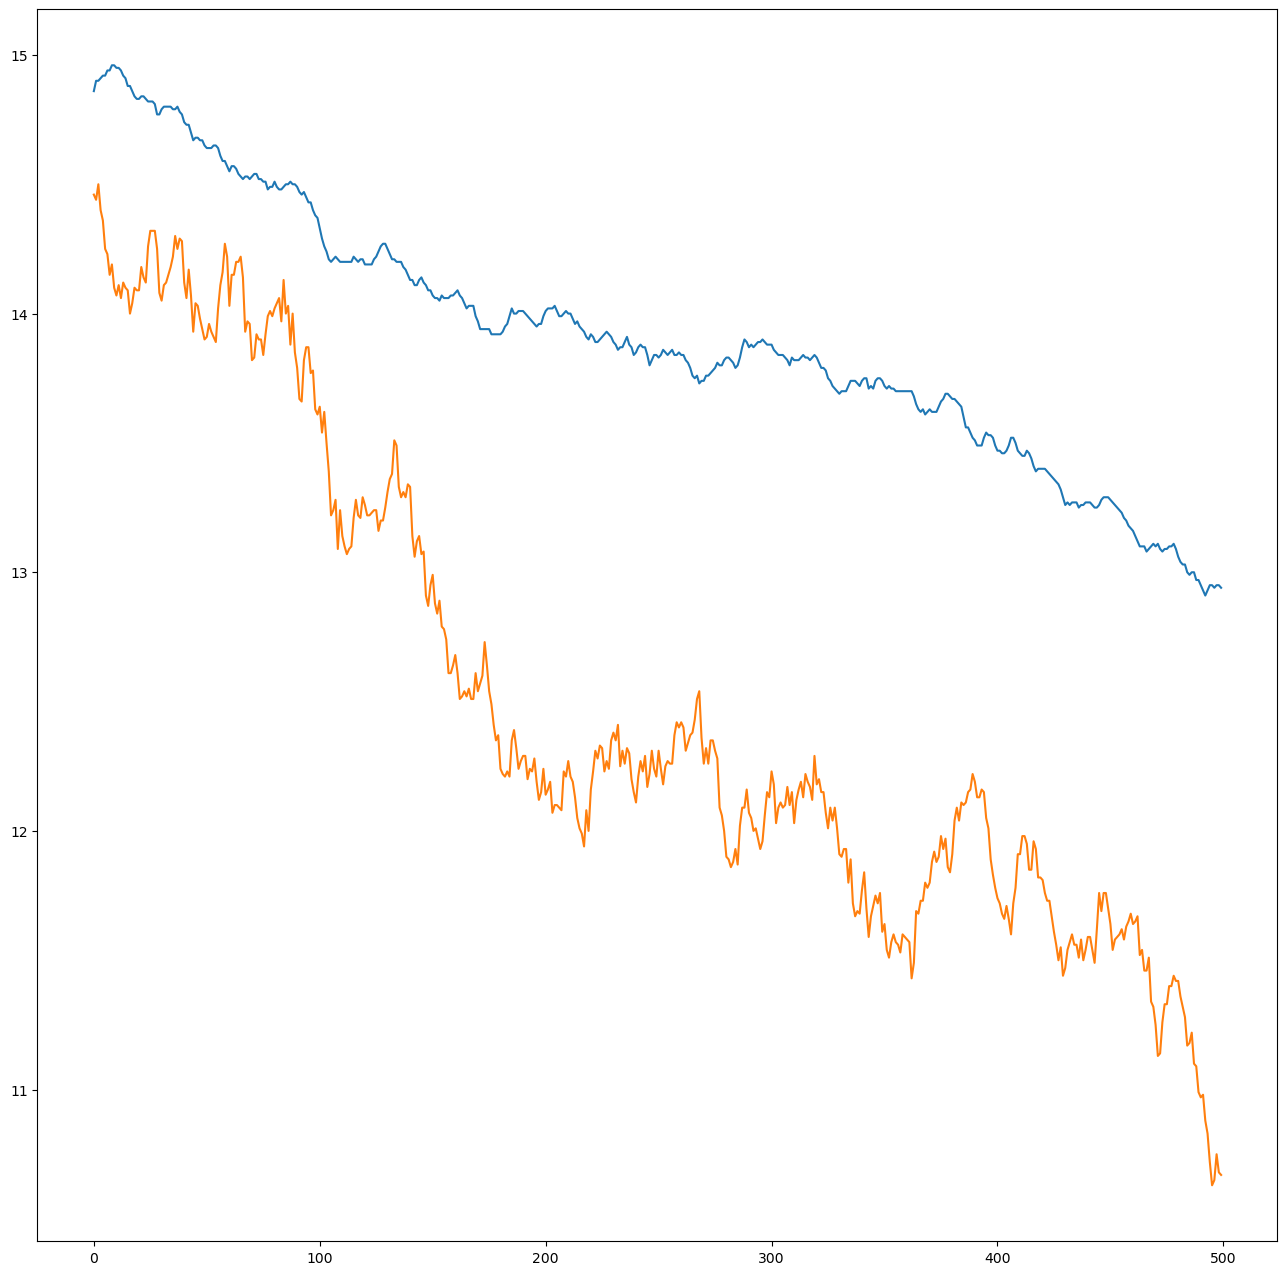

In [100]:
fig, ax = subplots(figsize = (16, 16))
ax.plot(prices[27] - 15)
ax.plot(prices[42])